## Diseñar y entrenar una arquitectura transformar para predecir los valores futuros de una sinusoidal.

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import torch
import sys
import os
# Añadir la carpeta src al path
sys.path.append(os.path.abspath("../src"))

from constructor_sinu import sinu_constructed,set_device,make_windows_1step
from mlp import BaseSinuRNN, TensorLoader


In [ ]:
x_np, y_np = sinu_constructed(0, 1, 50, 2, 4*np.pi, -np.pi)
device = set_device()

y = torch.from_numpy(y_np).float()
y_train = y[:40].to(device)   # conocidos
y_true  = y[40:].to(device)   # reales futuros (solo para comparar)

# ventanas
L = 10
X_train, Y_train = make_windows_1step(y_train, L=L)  # (N,L,1) y (N,1)

# modelo + optim
model = BaseSinuRNN(input_size=1, hidden_size=32, batch_first=True).to(device)
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# entrenar con TU función
%time TensorLoader.train(X_train, Y_train, model, loss_fn, optimizer, epochs=2000, bs=16, device=device, trace=200)

Using cuda device
loss: 0.000281 [  200 / 2000]
loss: 0.000034 [  400 / 2000]
loss: 0.000016 [  600 / 2000]
loss: 0.000023 [  800 / 2000]
loss: 0.000013 [ 1000 / 2000]
loss: 0.000437 [ 1200 / 2000]
loss: 0.000047 [ 1400 / 2000]
loss: 0.000139 [ 1600 / 2000]
loss: 0.000140 [ 1800 / 2000]
loss: 0.000132 [ 2000 / 2000]
CPU times: user 10.4 s, sys: 3.6 s, total: 14 s
Wall time: 12.8 s


In [ ]:
@torch.no_grad()
def predict_next_10(model, y_seed, L=10, steps=10, device='cpu'):
    model.eval()
    window = y_seed[-L:].view(1, L, 1).to(device)
    preds = []
    for _ in range(steps):
        yhat = model(window)          
        preds.append(yhat.item())
        window = torch.cat([window[:, 1:, :], yhat.view(1,1,1)], dim=1)
    return np.array(preds)

pred10 = predict_next_10(model, y_train, L=L, steps=10, device=device)
print("pred10:", pred10)
print("true10:", y_true.detach().cpu().numpy())

pred10: [1.46816492 1.76346397 1.94355774 1.99961591 1.92807817 1.730304
 1.41933835 1.02093291 0.56183487 0.06554119]
true10: [1.4805560e+00 1.7731986e+00 1.9498558e+00 1.9989724e+00 1.9173357e+00
 1.7102855e+00 1.3913651e+00 9.8143512e-01 5.0730914e-01 7.3478806e-16]


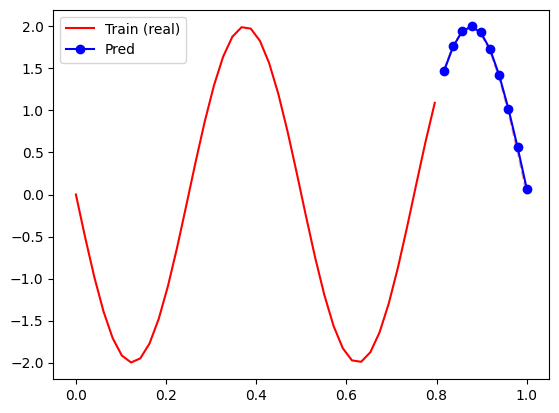

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Señal original
plt.plot(x_np[:40], y_np[:40], 'r', label='Train (real)')

# Zona real futura (opcional)
plt.plot(x_np[40:], y_np[40:], 'r--', alpha=0.4)

# Predicciones (azul)
x_future = x_np[40:40+len(pred10)]
plt.plot(x_future, pred10, 'b', marker='o', label='Pred')

plt.legend()
plt.show()